In [2]:
!pip install --upgrade rdkit

# Or if that doesn't work, force reinstall both
#!pip install --force-reinstall pandas numpy

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for rdkit from https://files.pythonhosted.org/packages/dc/6d/67d1304486317ac9417aa1ca7ec3e1bbed636f554f48d5be3b90d318da75/rdkit-2025.9.4-cp311-cp311-manylinux_2_28_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 91.4 MB/s eta 0:00:00:00:0100:01


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rdkit
import xgboost
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GroupKFold
from rdkit import RDLogger

# Disable all RDKit warnings
RDLogger.DisableLog('rdApp.*')# hydrogen warning pops up, due to [H] fragments

In [2]:
# helper functions for fingerprints and data mapping
def smiles_to_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nBits)
    return np.array(
        AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    )

def build_fp_block(df, col):
    return np.vstack(df[col].apply(smiles_to_fp).values)
# Build SEPARATE XYZ mappings for each dataset
def map_smiles_to_xyz(smiles_series, xyz_map, column_name):
    result = []
    missing = []
    
    for smi in smiles_series:
        if smi in xyz_map.index:
            result.append(xyz_map[smi])
        else:
            result.append(None)
            missing.append(smi)
    
    if missing:
        print(f"Warning: {len(missing)} SMILES in '{column_name}' not found in XYZ map")
        print(f"First 5 missing: {missing[:5]}")
    
    return pd.Series(result, index=smiles_series.index)

In [7]:

print("\nLoading BDE data...")

# Load anion (deprotonated) data
#df_QM_full_anion = pd.read_csv("Anion_table_full.csv")
df_anion = pd.read_csv("../Data/Enthalpy_Anion_BDE_table.csv")
df_anion = df_anion.dropna()
df_anion = df_anion.drop(columns=['BDEhet_wB97X-V', 'Bond_Index'])
df_anion['solvent'] = 'water'

# Load neutral (protonated) data
#df_QM_full_neutral = pd.read_csv("Neutral_table_full.csv")
df_neutral = pd.read_csv("../Data/Enthalpy_Neutral_BDE_table.csv")
df_neutral = df_neutral.dropna()
df_neutral = df_neutral.drop(columns=['Bond_Index'])
df_neutral['solvent'] = 'gas'

# Combine datasets
df = pd.concat([df_anion, df_neutral], ignore_index=True)

print(f"\n{'='*60}")
print(f"DATASET SUMMARY")
print(f"{'='*60}")
print(f"Total bonds: {len(df)}")
print(f"  - Water (deprotonated): {len(df[df['solvent']=='water'])}")
print(f"  - Gas (neutral): {len(df[df['solvent']=='gas'])}")
print(f"\nUnique molecules: {df['Parent_SMILES'].nunique()}")
print(f"BDE range: {df['BDE_wB97X-V'].min():.2f} - {df['BDE_wB97X-V'].max():.2f} kcal/mol")
print(f"BDE std: {df['BDE_wB97X-V'].std():.2f} kcal/mol")
print(f"{'='*60}\n")

df.head()


Loading BDE data...

DATASET SUMMARY
Total bonds: 701
  - Water (deprotonated): 283
  - Gas (neutral): 418

Unique molecules: 81
BDE range: 62.13 - 130.75 kcal/mol
BDE std: 15.08 kcal/mol



,Parent_SMILES,Frag1_SMILES,Frag2_SMILES,BDE_wB97X-V,solvent
0,[H]C([H])([H])S(=O)(=O)[O-],[H][C]([H])[H],O=[S](=O)[O-],77.996727,water
1,[H]C([H])([H])S(=O)(=O)[O-],[H][C]([H])S(=O)(=O)[O-],[H],105.602360,water
2,[H]C([H])([H])C(=O)[O-],[H][C]([H])[H],O=[C][O-],85.924202,water
3,[H]C([H])([H])C(=O)[O-],[H][C]([H])C(=O)[O-],[H],99.409015,water
4,[H]C([H])(F)S(=O)(=O)[O-],[H][C]([H])S(=O)(=O)[O-],[F],113.520421,water


In [8]:
from sklearn.model_selection import learning_curve
y = df['BDE_wB97X-V'].values
X_parent = build_fp_block(df, 'Parent_SMILES')
X_frag1 = build_fp_block(df, 'Frag1_SMILES')
X_frag2 = build_fp_block(df, 'Frag2_SMILES')

# Encode categorical features
enc = OneHotEncoder(sparse_output=False)
X_solvent = enc.fit_transform(df[['solvent']])


# Combine categorical features into "flags"
X_flags = np.hstack([X_solvent])

# Full feature set
X = np.hstack([X_parent, X_frag1, X_frag2, X_flags])
#kfold test
groups = df['Parent_SMILES'].values
gkf = GroupKFold(n_splits=5)


model = Ridge(alpha=1.0)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=model,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10),  # Use 10%, 20%, ..., 100% of data
    cv=gkf,  # Use your GroupKFold to respect molecule groups
    groups=groups,  # Pass your groups
    scoring='neg_mean_absolute_error',  # Negative because sklearn minimizes
    n_jobs=-1  # Use all CPU cores (faster)
)
print("finished")

finished


In [23]:
#groups

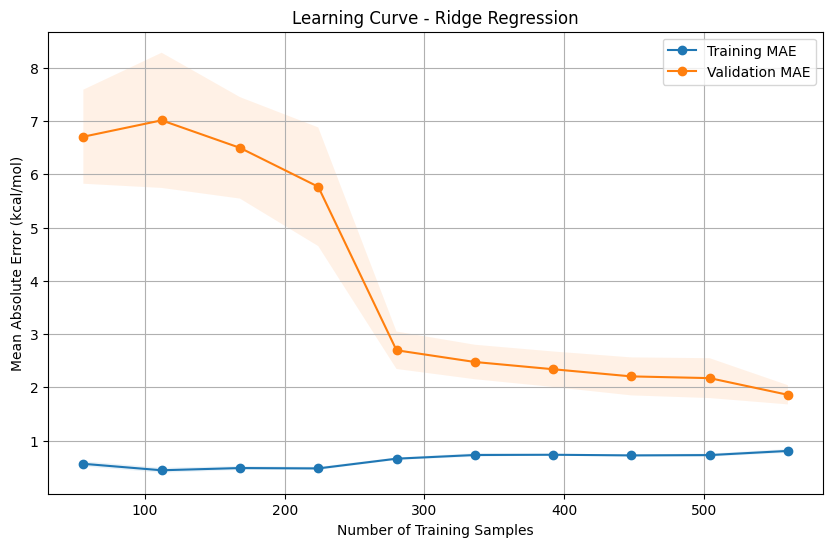

In [9]:
# Step 5: Calculate mean and std for plotting
train_mean = -train_scores.mean(axis=1)  # Negative because sklearn returns negative MAE
train_std = train_scores.std(axis=1)
val_mean = -val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# Step 6: Create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training MAE', marker='o')
plt.plot(train_sizes, val_mean, label='Validation MAE', marker='o')

# Optional: Add shaded regions for standard deviation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)

plt.xlabel('Number of Training Samples')
plt.ylabel('Mean Absolute Error (kcal/mol)')
plt.title('Learning Curve - Ridge Regression')
plt.legend()
plt.grid(True)
plt.show()

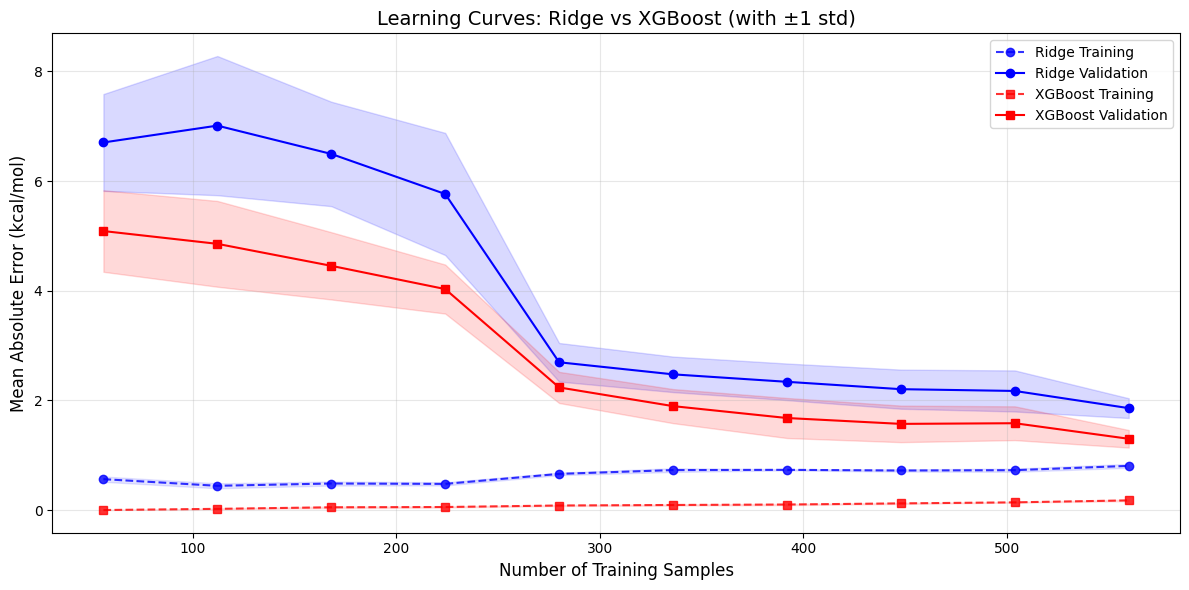

In [32]:
# Step 1: Create XGBoost model
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    colsample_bytree=0.7,
    gamma=0,
    learning_rate=0.2,
    max_depth=6,
    min_child_weight=1,
    n_estimators=200,
    subsample=0.9,
    random_state=42,
    n_jobs=-1,
    verbosity=0 )

# Step 2: Generate learning curve
train_sizes_xgb, train_scores_xgb, val_scores_xgb = learning_curve(
    estimator=xgb_model,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=gkf,
    groups=groups,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Step 3: Calculate means AND standard deviations
train_mean_xgb = -train_scores_xgb.mean(axis=1)
train_std_xgb = train_scores_xgb.std(axis=1)  # ← Add this
val_mean_xgb = -val_scores_xgb.mean(axis=1)
val_std_xgb = val_scores_xgb.std(axis=1)      # ← Add this

# Step 4: Plot with shaded standard deviation
plt.figure(figsize=(12, 6))

# Ridge (with std)
plt.plot(train_sizes, train_mean, label='Ridge Training', marker='o', linestyle='--', color='blue', alpha=0.8)
plt.plot(train_sizes, val_mean, label='Ridge Validation', marker='o', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')

# XGBoost (with std)
plt.plot(train_sizes_xgb, train_mean_xgb, label='XGBoost Training', marker='s', linestyle='--', color='red', alpha=0.8)
plt.plot(train_sizes_xgb, val_mean_xgb, label='XGBoost Validation', marker='s', color='red')
plt.fill_between(train_sizes_xgb, train_mean_xgb - train_std_xgb, train_mean_xgb + train_std_xgb, alpha=0.1, color='red')
plt.fill_between(train_sizes_xgb, val_mean_xgb - val_std_xgb, val_mean_xgb + val_std_xgb, alpha=0.15, color='red')

plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('Mean Absolute Error (kcal/mol)', fontsize=12)
plt.title('Learning Curves: Ridge vs XGBoost (with ±1 std)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
val_mean_xgb
#train_sizes_xgb
print(f"XGBoost: {xgboost.__version__}")
print(f"Numpy: {np.__version__}")
#print(f"python: {python.__version__}")
!python3 --version

XGBoost: 3.1.3
Numpy: 1.26.4
Python 3.11.5


## Model Diagnosis

In [11]:
# Step 1: Get predictions from your best model (XGBoost)
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(xgb_model, X, y, cv=gkf, groups=groups)

# Step 2: Calculate residuals
residuals = y - y_pred

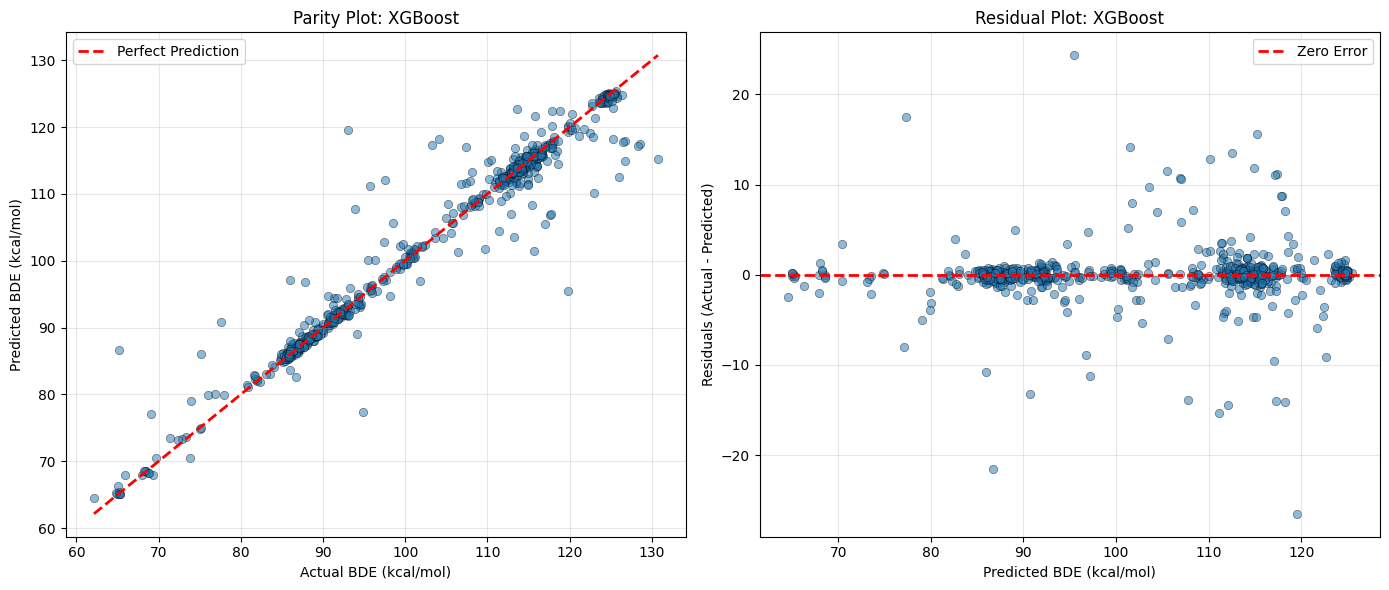

In [12]:
# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Parity Plot (Predicted vs Actual)
axes[0].scatter(y, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual BDE (kcal/mol)')
axes[0].set_ylabel('Predicted BDE (kcal/mol)')
axes[0].set_title('Parity Plot: XGBoost')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual Plot (Residuals vs Predicted)
axes[1].scatter(y_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Predicted BDE (kcal/mol)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot: XGBoost')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Add predictions and errors to your dataframe
df['predicted_BDE'] = y_pred
df['error'] = np.abs(y - y_pred)  # Absolute error
df['residual'] = y - y_pred  # Signed residual

# By solvent
print("Error by Solvent:")
print(df.groupby('solvent')['error'].agg(['mean', 'std', 'count']))
print()

# By bond type (if you have it)
if 'bond_type' in df.columns:
    print("Error by Bond Type:")
    print(df.groupby('bond_type')['error'].agg(['mean', 'std', 'count']))

Error by Solvent:
             mean       std  count
solvent                           
gas      1.726349  3.512783    418
water    0.666732  1.171016    283



In [14]:
# Sort by error to find worst predictions
worst_predictions = df.nlargest(20, 'error')

# Look at the key info
print("Top 20 Worst Predictions:")
print(worst_predictions[['Parent_SMILES', 'solvent', 'BDE_wB97X-V', 'predicted_BDE', 'error']])

Top 20 Worst Predictions:
                                         Parent_SMILES solvent  BDE_wB97X-V  \
374             [H]OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F     gas    93.025413   
332                           [H]OC(=O)C(F)(F)C(F)(F)F     gas   119.832589   
564  [H]OS(=O)(=O)C(F)(OC(F)(F)C(F)(F)C(F)(F)F)C(F)...     gas    65.128859   
551     [H]OC(=O)C(F)(OC(F)(F)C(F)(F)C(F)(F)F)C(F)(F)F     gas    94.811598   
290                                          FC(F)(F)F     gas   130.751409   
303                                [H]OC(=O)C([H])(F)F     gas    95.749158   
308                                  [H]OC(=O)C(F)(F)F     gas    97.600804   
668                                    FS(F)(F)(F)(F)F     gas   104.132314   
293                            [H]OC(=O)C([H])([H])[H]     gas   115.667539   
508  [H]OC(=O)C([H])([H])C([H])([H])C(F)(F)C(F)(F)C...     gas   103.309548   
559     [H]OC(=O)C(F)(OC(F)(F)C(F)(F)C(F)(F)F)C(F)(F)F     gas    93.898855   
669                       

### Feature IMportance

In [15]:
# Step 1: Train your XGBoost model on full data
xgb_model.fit(X, y)

# Step 2: Get feature importances
importances = xgb_model.feature_importances_

# Step 3: We need feature names
# Your features are: parent fingerprints, frag1 fingerprints, frag2 fingerprints, solvent
n_parent = X_parent.shape[1]
n_frag1 = X_frag1.shape[1]
n_frag2 = X_frag2.shape[1]
n_solvent = X_solvent.shape[1]

feature_names = (
    [f'parent_{i}' for i in range(n_parent)] +
    [f'frag1_{i}' for i in range(n_frag1)] +
    [f'frag2_{i}' for i in range(n_frag2)] +
    list(enc.get_feature_names_out(['solvent']))
)

In [16]:
# Step 4: Create a dataframe of feature importances
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Step 5: Look at top 20 most important features
print("Top 20 Most Important Features:")
print(feat_imp_df.head(20))

# Step 6: Aggregate by feature type (parent vs frag1 vs frag2 vs solvent)
def get_feature_type(name):
    if name.startswith('parent_'):
        return 'parent'
    elif name.startswith('frag1_'):
        return 'frag1'
    elif name.startswith('frag2_'):
        return 'frag2'
    else:
        return 'solvent'

feat_imp_df['type'] = feat_imp_df['feature'].apply(get_feature_type)

# Step 7: Sum importance by type
print("\nImportance by Feature Type:")
print(feat_imp_df.groupby('type')['importance'].sum().sort_values(ascending=False))

Top 20 Most Important Features:
         feature  importance
6015  frag2_1919    0.214407
4903   frag2_807    0.107763
5353  frag2_1257    0.104780
6024  frag2_1928    0.064821
3313  frag1_1265    0.050944
4523   frag2_427    0.042587
2475   frag1_427    0.035122
4770   frag2_674    0.025654
4811   frag2_715    0.024769
3976  frag1_1928    0.023928
4276   frag2_180    0.022355
5462  frag2_1366    0.019938
650   parent_650    0.016068
694   parent_694    0.015384
2077    frag1_29    0.010708
4242   frag2_146    0.009961
3967  frag1_1919    0.008336
3414  frag1_1366    0.007519
2763   frag1_715    0.007357
4235   frag2_139    0.007098

Importance by Feature Type:
type
frag2      0.676841
frag1      0.229365
parent     0.093395
solvent    0.000398
Name: importance, dtype: float32


In [17]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
xgb_model.fit(X_train, y_train)

# Step 3: Get baseline performance on TEST set
y_pred_test = xgb_model.predict(X_test)
baseline_mae = mean_absolute_error(y_test, y_pred_test)
print(f"Baseline MAE: {baseline_mae:.3f}")

# Function to shuffle a feature block and measure performance
def permutation_importance_block_proper(X_test, y_test, model, start_idx, end_idx):
    X_test_permuted = X_test.copy()
    # Shuffle just this block in TEST set
    X_test_permuted[:, start_idx:end_idx] = np.random.permutation(X_test_permuted[:, start_idx:end_idx])
    
    y_pred_permuted = model.predict(X_test_permuted)
    permuted_mae = mean_absolute_error(y_test, y_pred_permuted)
    
    importance = permuted_mae - baseline_mae
    return importance
# Calculate for each block
# Step 5: Calculate permutation importance for each block (on TEST set)
print("\nPermutation Importance by Feature Block (Proper Train/Test Split):")
print("=" * 60)

# Run each block multiple times to get stable estimates
n_repeats = 10

def get_block_importance(start, end, name):
    importances = []
    for _ in range(n_repeats):
        imp = permutation_importance_block_proper(X_test, y_test, xgb_model, start, end)
        importances.append(imp)
    return np.mean(importances), np.std(importances)

parent_mean, parent_std = get_block_importance(0, parent_end, 'parent')
frag1_mean, frag1_std = get_block_importance(parent_end, frag1_end, 'frag1')
frag2_mean, frag2_std = get_block_importance(frag1_end, frag2_end, 'frag2')
solvent_mean, solvent_std = get_block_importance(frag2_end, solvent_end, 'solvent')

print(f"Parent:  {parent_mean:+.3f} ± {parent_std:.3f} MAE")
print(f"Frag1:   {frag1_mean:+.3f} ± {frag1_std:.3f} MAE")
print(f"Frag2:   {frag2_mean:+.3f} ± {frag2_std:.3f} MAE")
print(f"Solvent: {solvent_mean:+.3f} ± {solvent_std:.3f} MAE")

Baseline MAE: 1.100

Permutation Importance by Feature Block (Proper Train/Test Split):


NameError: name 'parent_end' is not defined

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for shap from https://files.pythonhosted.org/packages/1b/c1/5166e6a382d6c2b83abd25b5c70dcd984ca37bedd304abc98e5ca9c6968c/shap-0.50.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for numpy>=2 from https://files.pythonhosted.org/packages/1b/46/6fa4ea94f1ddf969b2ee941290cca6f1bfac92b53c76ae5f44afe17ceb69/numpy-2.4.2-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Using cached numpy-2.4.2-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Obtaining dependency information for slicer==0.0.8 from https://files.pythonhosted.org/packages/63/81/9ef641ff4e12cbcca30e54e72fb0951a2ba195d0cda0ba4100e532d929db/slicer-0.0.8-py3-none-any.whl.metadata
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirement

In [26]:
# Install if needed: pip install shap
import shap
import cloudpickle

# Step 2: Create SHAP explainer for your trained model
explainer = shap.TreeExplainer(xgb_model)

# Step 3: Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

ModuleNotFoundError: No module named 'cloudpickle'